<a href="https://colab.research.google.com/github/matteobosco0203/astrostatistics_bicocca_2026/blob/main/working/L22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
!pip install tensorflow

In [5]:
import tensorflow

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [7]:
data=pd.read_csv("galaxyquasar.csv", sep=",")

In [8]:
u_g=data['u']-data['g']
g_r=data['g']-data['r']
r_i=data['r']-data['i']
i_z=data['i']-data['z']
z=data['z1']

In [9]:
y=np.zeros(len(data['class']))
y[data['class']=='QSO']=1

from sklearn.model_selection import train_test_split

X=np.array([u_g,g_r,r_i,i_z])
X=X.transpose()
X_train_full, X_test = train_test_split(X, test_size=0.2, random_state=42)
y_train_full, y_test = train_test_split(y, test_size=0.2, random_state=42)



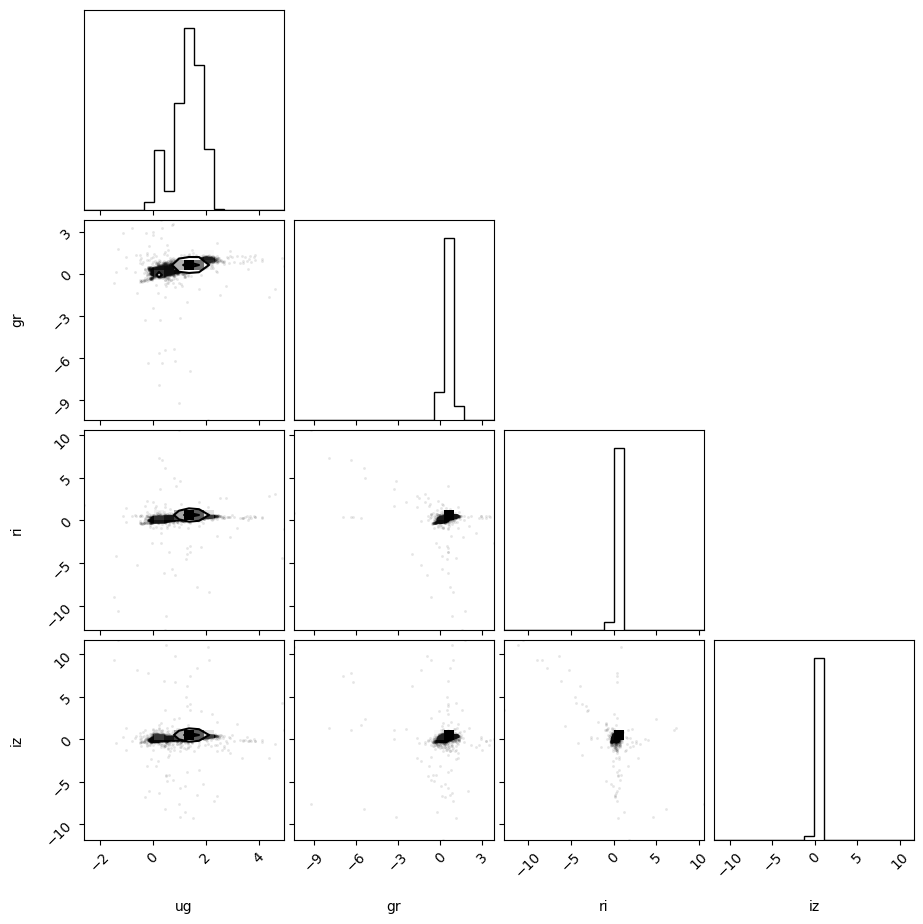

In [10]:
!pip install corner
import corner
corner.corner(X_train_full, labels=['ug', 'gr', 'ri', 'iz']);

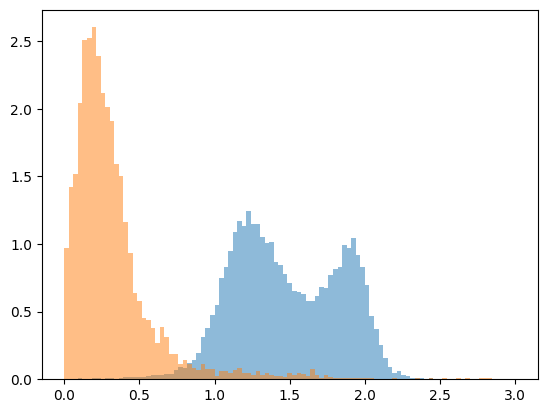

In [11]:
plt.hist(X_train_full[:,0][y_train_full==0], bins=np.linspace(0,3,100), density=True, alpha=0.5)
plt.hist(X_train_full[:,0][y_train_full==1], bins=np.linspace(0,3,100), density=True, alpha=0.5);

In [12]:
from tensorflow import keras

In [13]:
import tensorflow as tf

keras.backend.clear_session()
np.random.seed(42)
tf.random.set_seed(42)

In [14]:
X_train, X_valid = X_train_full[:-5000], X_train_full[-5000:]
y_train, y_valid = y_train_full[:-5000], y_train_full[-5000:]

X_train = X_train[:, :, np.newaxis]
X_valid = X_valid[:, :, np.newaxis]
X_test = X_test[:, :, np.newaxis]


In [15]:
model = keras.models.Sequential([
    keras.layers.InputLayer(input_shape=[4, 1]),
    keras.layers.Conv1D(filters=64, kernel_size=7, activation='relu', padding='same'),
    keras.layers.MaxPooling1D(pool_size=2),
    keras.layers.Conv1D(128, 3, activation='relu', padding='same'),
    keras.layers.Conv1D(128, 3, activation='relu', padding='same'),
    keras.layers.MaxPooling1D(pool_size=1),
    keras.layers.Conv1D(256, 3, activation='relu', padding='same'),
    keras.layers.Conv1D(256, 3, activation='relu', padding='same'),
    keras.layers.Flatten(),
    keras.layers.Dense(units=128, activation='relu'),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(units=64, activation='relu'),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(units=10, activation='softmax'),
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


In [16]:
print(model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 4, 64)          │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 2, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 2, 128)         │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 2, 128)         │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 2, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 2, 256)         │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 2, 256)         │       196,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 444,490 (1.70 MB)

 Trainable params: 444,490 (1.70 MB)

 Non-trainable params: 0 (0.00 B)

None


In [17]:
model.compile(loss="sparse_categorical_crossentropy", optimizer=keras.optimizers.Nadam(learning_rate=0.0001), metrics=["accuracy"])
clf = model.fit(X_train, y_train, epochs=20, validation_data=(X_valid, y_valid))

Epoch 1/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 58s 44ms/step - accuracy: 0.9223 - loss: 0.2898 - val_accuracy: 0.9830 - val_loss: 0.0722
Epoch 2/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 64s 27ms/step - accuracy: 0.9805 - loss: 0.0967 - val_accuracy: 0.9850 - val_loss: 0.0624
Epoch 3/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 32s 29ms/step - accuracy: 0.9828 - loss: 0.0806 - val_accuracy: 0.9846 - val_loss: 0.0587
Epoch 4/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 41s 29ms/step - accuracy: 0.9835 - loss: 0.0721 - val_accuracy: 0.9860 - val_loss: 0.0548
Epoch 5/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 30s 28ms/step - accuracy: 0.9843 - loss: 0.0691 - val_accuracy: 0.9858 - val_loss: 0.0555
Epoch 6/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 32s 30ms/step - accuracy: 0.9843 - loss: 0.0646 - val_accuracy: 0.9868 - val_loss: 0.0516
Epoch 7/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 30s 28ms/step - accuracy: 0.9844 - loss: 0.0629 - val_accuracy: 0.9866 - val_loss: 0.0506
Epoch 8/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 30s 28ms/step - accuracy: 0.9850 -

In [18]:
import sklearn
y_pred=np.argmax(model.predict(X_test), axis=-1)
print(sklearn.metrics.confusion_matrix(y_pred, y_test))

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
[[8492   79]
 [  80 1349]]


In [19]:
!pip install astroML
from astroML.utils import completeness_contamination
completeness, contamination= completeness_contamination(y_pred,y_test)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.3/134.3 kB 4.4 MB/s eta 0:00:00


In [20]:
def predict_prob(number):
  return [number[0],1-number[0]]

y_prob = np.array(list(map(predict_prob, model.predict(X_valid))))[:,1]
y_prob.shape

157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


(5000,)

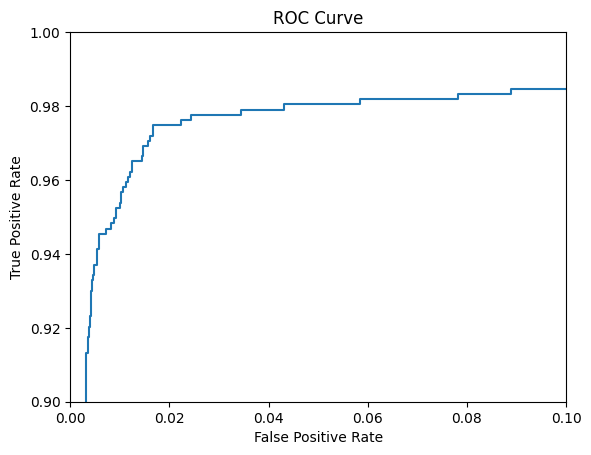

In [21]:
from sklearn.metrics import precision_recall_curve, roc_curve

fpr, tpr, thresh = roc_curve(y_valid, y_prob)
plt.plot(fpr,tpr)
plt.xlim(0,0.1)
plt.ylim(0.9,1)
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate");

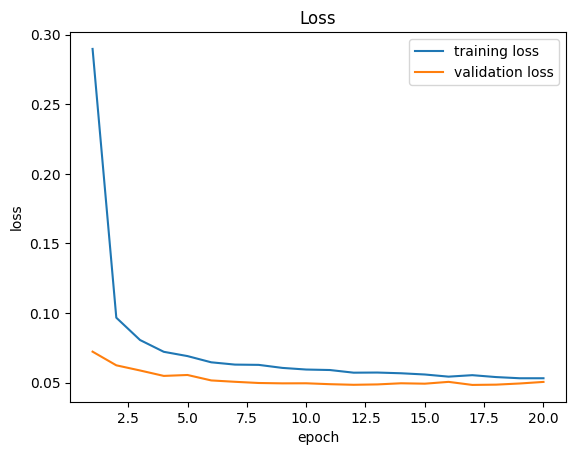

In [22]:
last_epoch = len(clf.history['loss'])
epochs = np.arange(1,last_epoch+1)
plt.plot(epochs,clf.history['loss'], label='training loss')
plt.plot(epochs,clf.history['val_loss'], label='validation loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.title('Loss')
plt.legend();

Max Accuracy:0.9869999885559082


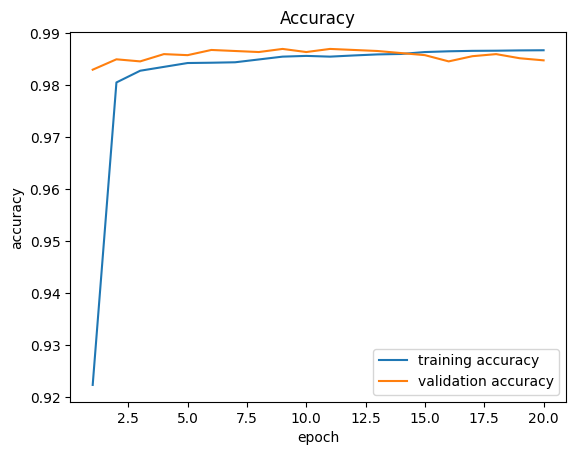

In [23]:
epochs = np.arange(1,last_epoch+1)
plt.plot(epochs,clf.history['accuracy'], label='training accuracy')
plt.plot(epochs,clf.history['val_accuracy'], label='validation accuracy')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.title('Accuracy')
plt.legend();
print("Max Accuracy:"+str(np.max(clf.history['val_accuracy'])))

Let's see what happens without dimensionality reduction and with an overall easier model!

In [31]:
model = keras.models.Sequential([
    keras.layers.InputLayer(input_shape=[4, 1]),
    keras.layers.Conv1D(filters=32, kernel_size=7, activation='relu', padding='same'),
    keras.layers.Dropout(0.5),
    keras.layers.Flatten(),
    keras.layers.Dense(units=64, activation='relu'),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(units=10, activation='softmax'),
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


In [32]:
print(model.summary())

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_5 (Conv1D)               │ (None, 4, 32)          │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 4, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,162 (35.79 KB)

 Trainable params: 9,162 (35.79 KB)

 Non-trainable params: 0 (0.00 B)

None


In [33]:
model.compile(loss="sparse_categorical_crossentropy", optimizer=keras.optimizers.Nadam(learning_rate=0.0001), metrics=["accuracy"])
clf = model.fit(X_train, y_train, epochs=20, validation_data=(X_valid, y_valid))

Epoch 1/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8374 - loss: 0.6147 - val_accuracy: 0.9446 - val_loss: 0.1649
Epoch 2/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9613 - loss: 0.1527 - val_accuracy: 0.9778 - val_loss: 0.0962
Epoch 3/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9741 - loss: 0.1124 - val_accuracy: 0.9792 - val_loss: 0.0885
Epoch 4/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9772 - loss: 0.1058 - val_accuracy: 0.9796 - val_loss: 0.0855
Epoch 5/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9779 - loss: 0.0969 - val_accuracy: 0.9800 - val_loss: 0.0830
Epoch 6/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9788 - loss: 0.0936 - val_accuracy: 0.9808 - val_loss: 0.0805
Epoch 7/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9793 - loss: 0.0899 - val_accuracy: 0.9810 - val_loss: 0.0784
Epoch 8/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9795 - loss: 0.0904 - 

In [34]:
import sklearn
y_pred=np.argmax(model.predict(X_test), axis=-1)
print(sklearn.metrics.confusion_matrix(y_pred, y_test))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
[[8490   92]
 [  82 1336]]


In [35]:
!pip install astroML
from astroML.utils import completeness_contamination
completeness, contamination= completeness_contamination(y_pred,y_test)

In [36]:
def predict_prob(number):
  return [number[0],1-number[0]]

y_prob = np.array(list(map(predict_prob, model.predict(X_valid))))[:,1]
y_prob.shape

157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


(5000,)

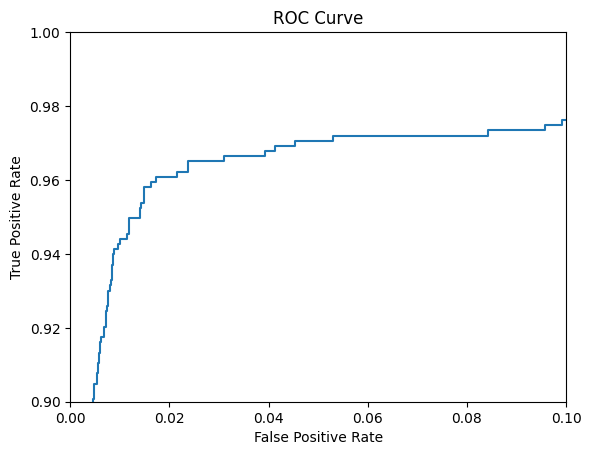

In [37]:
from sklearn.metrics import precision_recall_curve, roc_curve

fpr, tpr, thresh = roc_curve(y_valid, y_prob)
plt.plot(fpr,tpr)
plt.xlim(0,0.1)
plt.ylim(0.9,1)
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate");

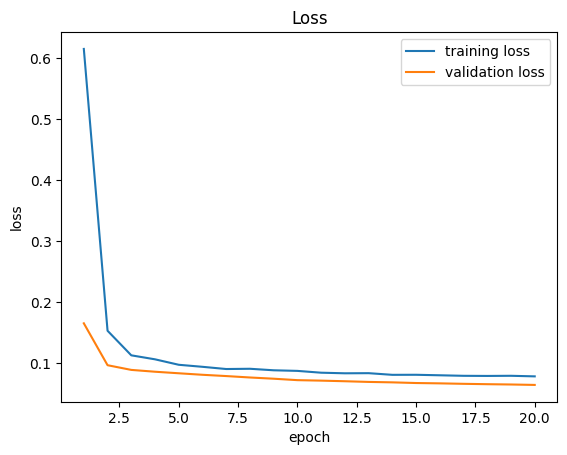

In [38]:
last_epoch = len(clf.history['loss'])
epochs = np.arange(1,last_epoch+1)
plt.plot(epochs,clf.history['loss'], label='training loss')
plt.plot(epochs,clf.history['val_loss'], label='validation loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.title('Loss')
plt.legend();

Max Accuracy:0.9836000204086304


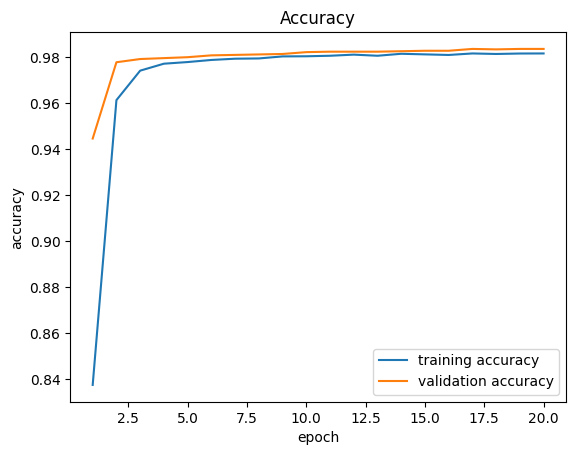

In [39]:
epochs = np.arange(1,last_epoch+1)
plt.plot(epochs,clf.history['accuracy'], label='training accuracy')
plt.plot(epochs,clf.history['val_accuracy'], label='validation accuracy')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.title('Accuracy')
plt.legend();
print("Max Accuracy:"+str(np.max(clf.history['val_accuracy'])))

Despite an easier model, we arrive at a very high accuracy!